# Assignment 1

- Write/implement your solutions in a copy of this notebook **without changing the structure**
- Finally submit in a **PDF** format (with proper outputs) by following `File -> Save and Export Notebook As -> PDF` and then upload
- The deadline for submitting the assignment is **May 12 midnight 23:59** 

## Sawtooth wave

Questions 1-3 and 5 are based on the following signal known as Sawtooth wave:

$x(t) = 2\left(\frac{t}{p} - \lfloor \frac{1}{2} + \frac{t}{p} \rfloor \right)$

where $p$ is period and $\lfloor \rfloor$ is floor function, i.e., rounds off a decimal to the nearest integer less than itself.

Consider frequency $f = 1/p$ = 200 Hz, the following is a plot of the signal 

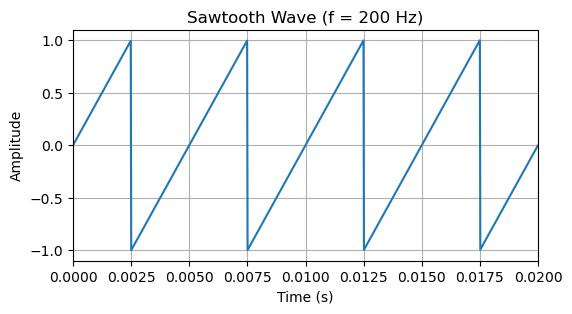

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
f = 200          # Hz
p = 1 / f        # period
t = np.linspace(0, 0.02, 1000)  # 20 ms (a few periods)

# sawtooth wave
x = 2 * (t/p - np.floor(0.5 + t/p))

# plot
plt.figure(figsize=(6,3))
plt.plot(t, x)
plt.xlim((0, 0.02))
plt.title("Sawtooth Wave (f = 200 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

### Q1: Sampling
Sample the wave at **(a) 8 kHz** and **(b) 1 kHz** (aliasing)

**Plot** the samples along with the curve over a 20ms window (like above), as well as play them and notice aliasing in (b)

(This curve corresponds to Hoover sound in electronic music produced using a synthesizer)

In [2]:
from IPython.display import Audio ## To play the arrays
### Your Code

### Q2: Fourier Series

The Fourier series of this curve is given by (use f = 200 Hz):

$x(t) = -\frac{2}{\pi}\sum_{k=1}^N\frac{(-1)^k}{k}\sin(2\pi fkt)$

Plot the series for **N = 1, 2, 3, 5** along with the original curve in one plot (for 20ms window). Notice how quickly the seriers converges to the signal with increasing N.

In [3]:
## Your Code

### Q3: Fourier Transform

Sample the signal at 8 kHz over a 20ms window, perform Discrete Fourier Transform via **FFT** and plot the **spectrum**.

In [4]:
## Your code, use the numpy module np.fft

## Convolution: Edge Detection

### Q4: Image filter

The following matrix is an image of a digit encoded in black and white, **apply** the Laplacian filter (L) defined below and **re-draw the image**. This filter detects edges.

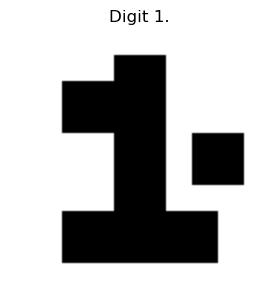

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# simple binary image of digit '1.'
img = np.ones((100, 100))
img[10:-10, 40:60] = 0   # vertical stroke
img[-30:-10, 20:80] = 0
img[20:40, 20:40] = 0
img[40:60, 70:90] = 0


# plot
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.title("Digit 1.")
plt.imshow(img, cmap='gray')
plt.axis('off')


plt.tight_layout()
plt.show()

In [6]:
from scipy.signal import convolve2d

# Laplacian filter (4-neighbour version)
L = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

## Apply convolution and re-draw

### Q5: Audio filter

Sample the previous Sawtooth wave at frequency **4 kHz** over a **1s** window. **Apply** a low pass filter by allowing frequencies $<$ **1 kHz** (less than Nyquist frequency of 2 kHz). In other words, apply FFT, cut frequencies above the threshold by multiplying with the filter, plot the spectrum before and after (0-4kHz). Then apply inverse FFT and then play the sound before and after applying filter. What do you notice?

In [7]:
## Your code here

## Praat
Q6-7 are based on using Praat

### Q6: Formants
Record your own utterances of vowels /a:/ as F**a**ther, /i:/ as in m**ee**k, /u:/ as in b**oo**t. Using Praat, note down the values of formant frequencies F1 and F2 and tabulate: 
| Vowel | F1 (Hz) | F2 (Hz) |
|-----|------|-----|
| /a:/ | VALUE | VALUE |
| /i:/ | VALUE | VALUE |
| /u:/ | VALUE | VALUE |

> Your Answer

### Q7: MFCCs
Compute MFCCs within Praat for the above vowels over a window of **at least 20ms**. What are their dimensions (lengths)?

> Your Answer

## Optional

The following questions involve mathematics and can be skipped if you are not comfortable

### (Optional) Q8: Orthogonality
Show that $\int_{0}^{2\pi}\cos(mx)\sin(nx)dx = 0$  $\forall m,n$ 

(Use the trigonometric identity $\sin(a)+\sin(b)=2\sin\left(\frac{a+b}{2}\right)\cos\left(\frac{a-b}{2}\right)$)

> Your Answer

### (Optional) Q9: Sampling in Frequency Domain
An impulse train (or a Dirac comb) with period $P$ is defined as:

> $\psi_P(t) = \sum_{n=-\infty}^{\infty}\delta(t-nP)$

where $\delta(x)$ is an impulse signal (or Dirac delta) with property: 

> $\int_{a-T}^{a+T}f(\tau)\delta(a-\tau)d\tau = f(a)$ for any $T > 0, a \in \mathbb{R}$. and $f(\tau)\delta(a-\tau) = f(a)\delta(a-\tau)$

Hence, sampling a signal $x(t)$ to get a sampled signal $x_S(t)$ with sampling period $P$ can be seen as a multiplication:

> $x_S(t) =  \sum_{n=-\infty}^{\infty} x(t)\delta(nP-t) = x(t)\psi_P(t)$


By Sampling Theorem it is convolution in frequency domain, $X_S(\omega) = \frac{1}{2\pi}(X*\Psi_P)(\omega)$

Show that $\Psi_P(\omega) = \int_{-\infty}^{\infty}\psi_P(t)e^{-i\omega t}dt = \frac{2\pi}{P}\sum_{k=-\infty}^{\infty}\delta\left(\omega - \frac{2\pi k}{P}\right)$

There by show that $X_S(\omega) = \frac{1}{P}\sum_{k=-\infty}^{\infty}X\left(\omega - \frac{2 \pi k}{P} \right)$, in other words, sampling **replicates its spectrum periodically** in frequency domain. Hence larger sampling period $P$ (i.e., smaller sampling frequency) results in aliasing.

You may use the identity $\sum_{k=-\infty}^{\infty}e^{-i\omega Pk} = \frac{2 \pi}{P}\sum_{k=-\infty}^{\infty}\delta\left(\omega - \frac{2 \pi k}{P} \right)$

> Your Answer